https://www.canva.com/design/DAHD7vQGNnY/hV7TnxcM6p2_rzNTr12GSA/edit

https://techdocs.gbif.org/en/openapi/

# GBIF EDA, Data Cleaning and Filtering Notebook

In [1]:
import os
import re

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

import plotly.graph_objects as go

### Settings

In [2]:
DATA_FOLDER = "data_csv"


species_dict = {}
species_dict["Apis mellifera"] = "Westliche Honigbiene"
species_dict["Bombus"] = "Hummeln"
species_dict["Dolichovespula"] = "Langkopfwespen"
species_dict["Vespula"] = "Kurzkopfwespen"
species_dict["Vespa crabro"] = "Europäische Hornisse"
species_dict["Vespa velutina"] = "Asiatische Hornisse"

# Species to download: common name → scientific name
SPECIES_MAP = {
    "European hornet": "Vespa crabro",
    "Asian hornet": "Vespa velutina",
}

COLORS = {
    # Vespa crabro
    "Vespa crabro":                                    "#e67e00",  # orange
    "Vespa crabro Linnaeus":                           "#e67e00",
    "Vespa crabro germana Christ, 1791":               "#c45e00",  # dunkelorange
    "Vespa crabro crabro":                             "#a03d00",  # braun-orange
    "BOLD:ABA8441":                                    "#7a2e00",  # dunkelbraun

    # Vespa velutina
    "Vespa velutina":                                  "#a83232",  # rot
    "Vespa velutina Lepeletier, 1836":                 "#a83282",
    "Vespa velutina nigrithorax Buysson, 1905":        "#a83432",  # dunkelblau

    'missing':          '#BDBDBD',   # grey
    'accent':           '#2ECC71',   # green
}

### Load Data

In [3]:
a_data = pd.read_csv(f'{DATA_FOLDER}/asian_hornet_DE.csv')
e_data= pd.read_csv(f'{DATA_FOLDER}/european_hornet_DE.csv')
df = pd.concat([a_data, e_data])

print(a_data.shape, e_data.shape, df.shape)

C:\Users\Awet\AppData\Local\Temp\ipykernel_32068\2921309016.py:1: DtypeWarning: Columns (69,71,72,73,74,78,103) have mixed types. Specify dtype option on import or set low_memory=False.
  a_data = pd.read_csv(f'{DATA_FOLDER}/asian_hornet_DE.csv')


(17866, 117) (61236, 141) (79102, 145)


C:\Users\Awet\AppData\Local\Temp\ipykernel_32068\2921309016.py:2: DtypeWarning: Columns (75,81,82,95,101,103,104,105,109,110,111,113,114,115,116,117,118,119,120,121,122,123,126,127,128,129,130,132,133,134,135,136,137,138,139,140) have mixed types. Specify dtype option on import or set low_memory=False.
  e_data= pd.read_csv(f'{DATA_FOLDER}/european_hornet_DE.csv')


In [4]:
df.head(n=3)

,key,datasetKey,publishingOrgKey,installationKey,hostingOrganizationKey,publishingCountry,protocol,lastCrawled,lastParsed,crawlId,...,institutionID,sampleSizeUnit,verbatimElevation,eventRemarks,higherClassification,georeferencedBy,georeferencedDate,municipality,county,locationAccordingTo
0,4148782383,9fd6c3da-88f7-4df7-9a3f-3f3f9c703998,1928bdf0-f5d2-11dc-8c12-b8a03c50a862,e44d0fd7-0edf-477f-aa82-50a81836ab46,1928bdf0-f5d2-11dc-8c12-b8a03c50a862,FR,DWC_ARCHIVE,2026-03-04T06:26:31.021+00:00,2026-03-04T06:34:03.803+00:00,365,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,4148782475,9fd6c3da-88f7-4df7-9a3f-3f3f9c703998,1928bdf0-f5d2-11dc-8c12-b8a03c50a862,e44d0fd7-0edf-477f-aa82-50a81836ab46,1928bdf0-f5d2-11dc-8c12-b8a03c50a862,FR,DWC_ARCHIVE,2026-03-04T06:26:31.021+00:00,2026-03-04T06:34:12.055+00:00,365,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,4949483878,aa6c5ee6-d4d7-4a65-a04f-379cffbf4842,2754e9c0-0e43-4f65-968a-6f16b9c378ce,dcceb601-2fb0-49dc-9cd2-7c00056f2b2c,2754e9c0-0e43-4f65-968a-6f16b9c378ce,DE,BIOCASE,2026-03-20T00:46:08.174+00:00,2026-03-20T00:58:05.699+00:00,384,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
df_base = df.copy()

print(df_base.shape)

(79102, 145)


In [6]:
base_cols = df_base.columns
print(base_cols)

Index(['key', 'datasetKey', 'publishingOrgKey', 'installationKey',
       'hostingOrganizationKey', 'publishingCountry', 'protocol',
       'lastCrawled', 'lastParsed', 'crawlId',
       ...
       'institutionID', 'sampleSizeUnit', 'verbatimElevation', 'eventRemarks',
       'higherClassification', 'georeferencedBy', 'georeferencedDate',
       'municipality', 'county', 'locationAccordingTo'],
      dtype='object', length=145)


In [7]:
[col for col in base_cols if "date" in col], [col for col in base_cols if "Date" in col]

(['dateIdentified'], ['eventDate', 'verbatimEventDate', 'georeferencedDate'])

### Check NA Columns

In [8]:
def nan_overview_f(df):
    nan_overview = pd.DataFrame({
        "non_null":  df.notna().sum(),
        "null":      df.isna().sum(),
        "null_%":    (df.isna().mean() * 100).round(1),
        "dtype":     df.dtypes,
    }).sort_values("null_%", ascending=False)

    return nan_overview

print(nan_overview_f(df))

                             non_null   null  null_%   dtype
locationAccordingTo                 2  79100   100.0  object
georeferenceSources                 2  79100   100.0  object
http://unknown.org/modified         4  79098   100.0  object
originalNameUsage                   4  79098   100.0  object
nameAccordingTo                     4  79098   100.0  object
...                               ...    ...     ...     ...
datasetKey                      79102      0     0.0  object
specificEpithet                 79073     29     0.0  object
genericName                     79073     29     0.0  object
gbifID                          79102      0     0.0   int64
key                             79102      0     0.0   int64

[145 rows x 4 columns]


In [9]:
nan_overview = nan_overview_f(df)

In [10]:
nan_overview_f(df[['dateIdentified','eventDate','verbatimEventDate','georeferencedDate']])

# georeferencedDate, verbatimEventDate and dateIdentified mostly empty, only eventDate full

,non_null,null,null_%,dtype
georeferencedDate,2,79100,100.0,object
verbatimEventDate,6584,72518,91.7,object
dateIdentified,14369,64733,81.8,object
eventDate,79102,0,0.0,object


In [11]:
nan100_cols = list(nan_overview[nan_overview["null_%"] == 100].index.values)
print(len(nan100_cols))
nan100_cols

31


['locationAccordingTo',
 'georeferenceSources',
 'http://unknown.org/modified',
 'originalNameUsage',
 'nameAccordingTo',
 'distanceFromCentroidInMeters',
 'recordNumber',
 'verbatimLabel',
 'institutionKey',
 'preparations',
 'elevationAccuracy',
 'taxonConceptID',
 'disposition',
 'organismQuantity',
 'organismQuantityType',
 'identificationQualifier',
 'verbatimCoordinateSystem',
 'http://unknown.org/language',
 'georeferencedDate',
 'scientificNameID',
 'http://unknown.org/taxonRankID',
 'http://unknown.org/species',
 'taxonRemarks',
 'institutionID',
 'county',
 'verbatimElevation',
 'language',
 'eventRemarks',
 'higherClassification',
 'georeferencedBy',
 'municipality']

In [12]:
nan50_cols = list(nan_overview[(nan_overview["null_%"] >= 50) & (nan_overview["null_%"] < 100)].index.values)
print(len(nan50_cols))
nan50_cols

42


['eventID',
 'identificationRemarks',
 'sampleSizeUnit',
 'verbatimIdentification',
 'footprintWKT',
 'bibliographicCitation',
 'projectId',
 'nomenclaturalCode',
 'higherGeographyID',
 'higherGeography',
 'networkKeys',
 'datasetID',
 'elevation',
 'fieldNumber',
 'informationWithheld',
 'dataGeneralizations',
 'occurrenceRemarks',
 'sex',
 'vitality',
 'dynamicProperties',
 'infraspecificEpithet',
 'identificationID',
 'http://unknown.org/captive_cultivated',
 'verbatimLocality',
 'verbatimEventDate',
 'datasetName',
 'http://unknown.org/nick',
 'taxonID',
 'identifiedBy',
 'dateIdentified',
 'habitat',
 'vernacularName',
 'samplingProtocol',
 'individualCount',
 'identificationVerificationStatus',
 'lifeStage',
 'eventTime',
 'rightsHolder',
 'stateProvince',
 'modified',
 'identifier',
 'occurrenceID']

In [13]:
nan20_cols = list(nan_overview[(nan_overview["null_%"] >= 20) & (nan_overview["null_%"] < 50)].index.values)
print(len(nan20_cols))
nan20_cols

4


['references', 'collectionCode', 'institutionCode', 'catalogNumber']

In [14]:
nan1_cols = list(nan_overview[(nan_overview["null_%"] >= 1) & (nan_overview["null_%"] < 20)].index.values)
print(len(nan1_cols))
nan1_cols

3


['locality', 'recordedBy', 'coordinateUncertaintyInMeters']

In [15]:
nan_cols = list(nan_overview[(nan_overview["null_%"] >= 20)].index.values)
print(len(nan_cols))

77


In [16]:
non_empty_cols = [col for col in base_cols if col not in nan_cols]
print(len(non_empty_cols))
non_empty_cols

68


['key',
 'datasetKey',
 'publishingOrgKey',
 'installationKey',
 'hostingOrganizationKey',
 'publishingCountry',
 'protocol',
 'lastCrawled',
 'lastParsed',
 'crawlId',
 'extensions',
 'basisOfRecord',
 'occurrenceStatus',
 'classifications',
 'taxonKey',
 'kingdomKey',
 'phylumKey',
 'classKey',
 'orderKey',
 'familyKey',
 'genusKey',
 'speciesKey',
 'acceptedTaxonKey',
 'scientificName',
 'scientificNameAuthorship',
 'acceptedScientificName',
 'kingdom',
 'phylum',
 'order',
 'family',
 'genus',
 'species',
 'genericName',
 'specificEpithet',
 'taxonRank',
 'taxonomicStatus',
 'decimalLatitude',
 'decimalLongitude',
 'coordinateUncertaintyInMeters',
 'continent',
 'gadm',
 'year',
 'month',
 'day',
 'eventDate',
 'startDayOfYear',
 'endDayOfYear',
 'issues',
 'lastInterpreted',
 'license',
 'isSequenced',
 'identifiers',
 'media',
 'facts',
 'relations',
 'isInCluster',
 'recordedBy',
 'dnaSequenceID',
 'geodeticDatum',
 'class',
 'countryCode',
 'recordedByIDs',
 'identifiedByIDs',


In [ ]:
# based on non_empty_cols

column_categories = {

    # CORE SPATIAL (high value)
    "spatial": [
        "decimalLatitude",
        "decimalLongitude",
        "coordinateUncertaintyInMeters",
        "geodeticDatum",
        #"continent",
        #"country",
        #"countryCode",
        #"gbifRegion",
        #"publishedByGbifRegion",
        #"locality",
        #"gadm",                        
    ],

    # TEMPORAL (high value) 
    "temporal": [
        "year",
        "month",
        "day",
        "eventDate",
        #"startDayOfYear",
        #"endDayOfYear",
        #"year_month",                  
    ],

    # TAXONOMIC IDENTITY (high value) 
    "taxonomic": [
        "scientificName",
        "acceptedScientificName",
        "scientificNameAuthorship",
        "species",
        "genus",
        "family",
        "order",
        "phylum",
        "class",
        "kingdom",
        "genericName",
        "specificEpithet",
        "taxonRank",
        "taxonomicStatus",
    ],

    # TAXONOMIC KEYS (low value for EDA, useful for joins/filtering) 
    "taxonomic_keys": [
        "taxonKey",
        "speciesKey",
        "genusKey",
        "familyKey",
        "orderKey",
        "classKey",
        "phylumKey",
        "kingdomKey",
        "acceptedTaxonKey",
    ],

    # OBSERVATION METADATA (medium value) 
    "observation_meta": [
        "basisOfRecord",               # HUMAN_OBSERVATION
        "occurrenceStatus",            
        "recordedBy",
        "recordedByIDs",
        "identifiedByIDs",
        "isSequenced",
        "dnaSequenceID",
        "media",                       # photos 
        "identifiers",
    ],

    # DATA QUALITY / FLAGS (medium value)
    "data_quality": [
        "issues",                      
        "isInCluster",                 
        "license",
        "classifications",
    ],

    # DATASET / PIPELINE PROVENANCE (low value for EDA) 
    "provenance": [
        "key",
        "gbifID",
        "datasetKey",
        "publishingOrgKey",
        "installationKey",
        "hostingOrganizationKey",
        "publishingCountry",
        "protocol",
        "crawlId",
        "extensions",
        "lastCrawled",
        "lastParsed",
        "lastInterpreted",
    ],

    # DROP CANDIDATES 
    "drop_candidates": [
        "facts",
        "relations",
    ],
}

# Quick-access flat lists by utility tier
HIGH_VALUE   = column_categories["spatial"] + column_categories["temporal"] + column_categories["taxonomic"]
MEDIUM_VALUE = column_categories["observation_meta"] + column_categories["data_quality"]
LOW_VALUE    = column_categories["taxonomic_keys"] + column_categories["provenance"]
DROP         = column_categories["drop_candidates"]
taxonomic_cols   = column_categories["taxonomic"]

In [18]:
nan_overview_f(df[HIGH_VALUE])

,non_null,null,null_%,dtype
coordinateUncertaintyInMeters,71970,7132,9.0,float64
decimalLatitude,78932,170,0.2,float64
geodeticDatum,78932,170,0.2,object
month,78958,144,0.2,float64
day,78958,144,0.2,float64
decimalLongitude,78932,170,0.2,float64
order,79102,0,0.0,object
taxonRank,79102,0,0.0,object
specificEpithet,79073,29,0.0,object
genericName,79073,29,0.0,object


In [19]:
nan_overview_f(df[MEDIUM_VALUE])

,non_null,null,null_%,dtype
recordedBy,71094,8008,10.1,object
basisOfRecord,79102,0,0.0,object
occurrenceStatus,79102,0,0.0,object
recordedByIDs,79102,0,0.0,object
identifiedByIDs,79102,0,0.0,object
isSequenced,79102,0,0.0,bool
dnaSequenceID,79102,0,0.0,object
media,79102,0,0.0,object
identifiers,79102,0,0.0,object
issues,79102,0,0.0,object


In [20]:
nan_overview_f(df[LOW_VALUE])

,non_null,null,null_%,dtype
taxonKey,79102,0,0.0,int64
speciesKey,79102,0,0.0,int64
lastParsed,79102,0,0.0,object
lastCrawled,79102,0,0.0,object
extensions,79102,0,0.0,object
crawlId,79102,0,0.0,int64
protocol,79102,0,0.0,object
publishingCountry,79102,0,0.0,object
hostingOrganizationKey,79102,0,0.0,object
installationKey,79102,0,0.0,object


In [21]:
nan_overview_f(df[DROP])

,non_null,null,null_%,dtype
facts,79102,0,0.0,object
relations,79102,0,0.0,object


### EDA Columns

#### observation_meta and data_quality

In [22]:
observation_meta_cols = column_categories["observation_meta"]
observation_meta_cols

['basisOfRecord',
 'occurrenceStatus',
 'recordedBy',
 'recordedByIDs',
 'identifiedByIDs',
 'isSequenced',
 'dnaSequenceID',
 'media',
 'identifiers']

In [23]:
df[observation_meta_cols].describe()

,basisOfRecord,occurrenceStatus,recordedBy,recordedByIDs,identifiedByIDs,isSequenced,dnaSequenceID,media,identifiers
count,79102,79102,71094,79102,79102,79102,79102,79102,79102
unique,6,1,25779,50,50,2,25,33514,79101
top,HUMAN_OBSERVATION,PRESENT,-233027529,[],[],False,[],[],[{'identifier': '286826318'}]
freq,78993,79102,6416,78910,78828,79026,79026,45520,2


In [24]:
# recordedBy, recordedByIDs, identifiedByIDs and dnaSequenceID provide no insight value, can be droppped

In [25]:
# identifiers can maybe be used to map to NABU Naturgucker App

In [26]:
df[df["identifiers"].str.contains("naturgucker")].shape

(42366, 145)

In [27]:
df[df["identifiers"].str.contains("NABU")].shape

(42366, 145)

In [28]:
# media is photo reference, but we can focus on other column to varify sightings (identificationVerificationStatus)

In [29]:
print(df[df.media.isna()].shape)
print(df[df.media.notna()].shape)


(0, 145)
(79102, 145)


In [30]:
df[df["media"].str.contains("[]", regex=False)].shape

(45520, 145)

In [31]:
df["photo"] = df["media"].str.contains("[]", regex=False).map({True: "No Photo", False: "Photo"})

C:\Users\Awet\AppData\Local\Temp\ipykernel_32068\1501010681.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["photo"] = df["media"].str.contains("[]", regex=False).map({True: "No Photo", False: "Photo"})


In [32]:
df.groupby("species")[["photo", "identificationVerificationStatus"]].value_counts(dropna=False).to_frame().assign(
    percent=lambda x: x["count"] / x.groupby("species")["count"].transform("sum") * 100
).sort_index(level=["species", "photo", "identificationVerificationStatus"])

# media columns sometimes empty for varified rows and sometimes they are varified without photo reference...

count  \
species        photo    identificationVerificationStatus                            
Vespa crabro   No Photo Approved | Automated                                 2261   
                        Approved | Expert                                      62   
                        Approved | Expert | Evidence                          277   
                        Valid                                                   9   
                        NaN                                                 30478   
               Photo    <a href='https://bee.questagame.com/#/expert/pa...      1   
                        <a href='https://bee.questagame.com/#/expert/pa...      1   
                        Approved | Automated                                 8076   
                        Approved | Expert                                    1220   
                        Approved | Expert | Evidence                         7415   
                        NaN                                                 11436   
Vespa velutina No Photo Approved | Automated                                   19   
                        Approved | Expert                                      11   
                        Approved | Expert | Evidence                           63   
                        Non réalisable                                          4   
                        Valid                                                 244   
                        NaN                                                 12092   
               Photo    Approved | Automated                                    5   
                        Approved | Expert                                     117   
                        Approved | Expert | Evidence                         1001   
                        NaN                                                  4310   

                                                                              percent  
species        photo    identificationVerificationStatus                               
Vespa crabro   No Photo Approved | Automated                                 3.692273  
                        Approved | Expert                                    0.101248  
                        Approved | Expert | Evidence                         0.452348  
                        Valid                                                0.014697  
                        NaN                                                 49.771376  
               Photo    <a href='https://bee.questagame.com/#/expert/pa...   0.001633  
                        <a href='https://bee.questagame.com/#/expert/pa...   0.001633  
                        Approved | Automated                                13.188321  
                        Approved | Expert                                    1.992292  
                        Approved | Expert | Evidence                        12.108890  
                        NaN                                                 18.675289  
Vespa velutina No Photo Approved | Automated                                 0.106347  
                        Approved | Expert                                    0.061569  
                        Approved | Expert | Evidence                         0.352625  
                        Non réalisable                                       0.022389  
                        Valid                                                1.365723  
                        NaN                                                 67.681630  
               Photo    Approved | Automated                                 0.027986  
                        Approved | Expert                                    0.654875  
                        Approved | Expert | Evidence                         5.602821  
                        NaN                                                 24.124034

In [33]:
df.groupby("species")[["isSequenced", "media", "identifiers"]].value_counts().to_frame().assign(
    percent=lambda x: x["count"] / x.groupby("species")["count"].transform("sum") * 100
)

count  \
species        isSequenced media                                              identifiers                                                 
Vespa crabro   False       []                                                 [{'identifier': '0003ca35-555b-5b26-bec7-5fbcf2...      1   
                           [{'type': 'StillImage', 'format': 'image/jpeg',... [{'identifier': 'urn:catalog:NABU|naturgucker:N...      1   
                           [{'type': 'StillImage', 'format': 'image/jpeg',... [{'identifier': 'urn:catalog:NABU|naturgucker:N...      1   
                           [{'type': 'StillImage', 'format': 'image/jpeg',... [{'identifier': 'urn:catalog:NABU|naturgucker:N...      1   
                           [{'type': 'StillImage', 'format': 'image/jpeg',... [{'identifier': 'urn:catalog:NABU|naturgucker:N...      1   
...                                                                                                                                 ...   
Vespa velutina False       []                                                 [{'identifier': 'cfbb7ad1-82bc-5ea2-9738-c11015...      1   
                                                                              [{'identifier': 'cfb54e98-bb47-5121-99e9-87ae70...      1   
                                                                              [{'identifier': 'cfb354b8-c8a1-54d0-8bec-46ee3b...      1   
                                                                              [{'identifier': 'cfb1c70a-0ff7-5210-803f-21e5d5...      1   
                           [{'type': 'StillImage', 'format': 'image/png', ... [{'identifier': '247654490'}]                           1   

                                                                                                                                   percent  
species        isSequenced media                                              identifiers                                                   
Vespa crabro   False       []                                                 [{'identifier': '0003ca35-555b-5b26-bec7-5fbcf2...  0.001633  
                           [{'type': 'StillImage', 'format': 'image/jpeg',... [{'identifier': 'urn:catalog:NABU|naturgucker:N...  0.001633  
                           [{'type': 'StillImage', 'format': 'image/jpeg',... [{'identifier': 'urn:catalog:NABU|naturgucker:N...  0.001633  
                           [{'type': 'StillImage', 'format': 'image/jpeg',... [{'identifier': 'urn:catalog:NABU|naturgucker:N...  0.001633  
                           [{'type': 'StillImage', 'format': 'image/jpeg',... [{'identifier': 'urn:catalog:NABU|naturgucker:N...  0.001633  
...                                                                                                                                    ...  
Vespa velutina False       []                                                 [{'identifier': 'cfbb7ad1-82bc-5ea2-9738-c11015...  0.005597  
                                                                              [{'identifier': 'cfb54e98-bb47-5121-99e9-87ae70...  0.005597  
                                                                              [{'identifier': 'cfb354b8-c8a1-54d0-8bec-46ee3b...  0.005597  
                                                                              [{'identifier': 'cfb1c70a-0ff7-5210-803f-21e5d5...  0.005597  
                           [{'type': 'StillImage', 'format': 'image/png', ... [{'identifier': '247654490'}]                       0.005597  

[79102 rows x 2 columns]

In [34]:
df.groupby("species")[["basisOfRecord", "occurrenceStatus"]].value_counts().to_frame().assign(
    percent=lambda x: x["count"] / x.groupby("species")["count"].transform("sum") * 100
)

# basisOfRecord mostly HUMAN_OBSERVATION, occurrenceStatus always PRESENT
# maybe only keep basisOfRecord: HUMAN_OBSERVATION

count     percent
species        basisOfRecord       occurrenceStatus                   
Vespa crabro   HUMAN_OBSERVATION   PRESENT           61127   99.822000
               MACHINE_OBSERVATION PRESENT              48    0.078385
               MATERIAL_SAMPLE     PRESENT              29    0.047358
               PRESERVED_SPECIMEN  PRESENT              28    0.045725
               OBSERVATION         PRESENT               2    0.003266
               OCCURRENCE          PRESENT               2    0.003266
Vespa velutina HUMAN_OBSERVATION   PRESENT           17866  100.000000

In [35]:
dq_cols = column_categories["data_quality"]
dq_cols

['issues', 'isInCluster', 'license', 'classifications']

In [36]:
df[dq_cols].describe()

,issues,isInCluster,license,classifications
count,79102,79102,79102,79102
unique,35,2,3,15
top,"['COORDINATE_ROUNDED', 'GEODETIC_DATUM_ASSUMED...",False,http://creativecommons.org/licenses/by/4.0/leg...,{'7ddf754f-d193-4cc9-b351-99906754a03b': {'usa...
freq,42451,77546,44761,54722


In [37]:
# dq_cols are secondary columns, not needed for further analysis

#### taxonomic_cols

In [38]:
df[taxonomic_cols].describe()

,scientificName,acceptedScientificName,scientificNameAuthorship,species,genus,family,order,phylum,class,kingdom,genericName,specificEpithet,taxonRank,taxonomicStatus
count,79102,79102,79065,79102,79102,79102,79102,79102,79102,79102,79073,79073,79102,79102
unique,6,6,4,2,1,1,1,1,1,1,1,2,3,1
top,Vespa crabro Linnaeus,Vespa crabro Linnaeus,Linnaeus,Vespa crabro,Vespa,Vespidae,Hymenoptera,Arthropoda,Insecta,Animalia,Vespa,crabro,SPECIES,ACCEPTED
freq,60614,60614,60614,61236,79102,79102,79102,79102,79102,79102,79073,61207,77303,79102


In [39]:
df.groupby("species")[["acceptedScientificName", "genericName", "scientificNameAuthorship"]].value_counts().to_frame().assign(
    percent=lambda x: x["count"] / x.groupby("species")["count"].transform("sum") * 100
)

# species seems enough -> acceptedScientificName, genericName and scientificNameAuthorship not needed

count  \
species        acceptedScientificName                   genericName scientificNameAuthorship          
Vespa crabro   Vespa crabro Linnaeus                    Vespa       Linnaeus                  60614   
               Vespa crabro germana Christ, 1791        Vespa       Christ, 1791                585   
Vespa velutina Vespa velutina Lepeletier, 1836          Vespa       Lepeletier, 1836          16689   
               Vespa velutina nigrithorax Buysson, 1905 Vespa       Buysson, 1905              1177   

                                                                                                percent  
species        acceptedScientificName                   genericName scientificNameAuthorship             
Vespa crabro   Vespa crabro Linnaeus                    Vespa       Linnaeus                  99.044102  
               Vespa crabro germana Christ, 1791        Vespa       Christ, 1791               0.955898  
Vespa velutina Vespa velutina Lepeletier, 1836          Vespa       Lepeletier, 1836          93.412068  
               Vespa velutina nigrithorax Buysson, 1905 Vespa       Buysson, 1905              6.587932

In [40]:
df.groupby("species")[["genus", "family", "specificEpithet"]].value_counts().to_frame().assign(
    percent=lambda x: x["count"] / x.groupby("species")["count"].transform("sum") * 100
)

# species seems enough -> genus, family and specificEpithet not needed

,,,,count,percent
species,genus,family,specificEpithet,,
Vespa crabro,Vespa,Vespidae,crabro,61207,100.0
Vespa velutina,Vespa,Vespidae,velutina,17866,100.0


In [41]:
df.groupby("species")[["order", "phylum", "class"]].value_counts().to_frame().assign(
    percent=lambda x: x["count"] / x.groupby("species")["count"].transform("sum") * 100
)

# species seems enough -> order, phylum and class not needed

,,,,count,percent
species,order,phylum,class,,
Vespa crabro,Hymenoptera,Arthropoda,Insecta,61236,100.0
Vespa velutina,Hymenoptera,Arthropoda,Insecta,17866,100.0


In [42]:
df.groupby("species")[["kingdom", "taxonRank", "taxonomicStatus"]].value_counts().to_frame().assign(
    percent=lambda x: x["count"] / x.groupby("species")["count"].transform("sum") * 100
)

# species seems enough -> kingdom, taxonRank and taxonomicStatus not needed
# Drop rows with taxonRank: UNRANKED Rows

count    percent
species        kingdom  taxonRank  taxonomicStatus                  
Vespa crabro   Animalia SPECIES    ACCEPTED         60614  98.984258
                        SUBSPECIES ACCEPTED           593   0.968385
                        UNRANKED   ACCEPTED            29   0.047358
Vespa velutina Animalia SPECIES    ACCEPTED         16689  93.412068
                        SUBSPECIES ACCEPTED          1177   6.587932

In [43]:
df.groupby("species")[["kingdom", "taxonRank", "scientificName"]].value_counts().to_frame().assign(
    percent=lambda x: x["count"] / x.groupby("species")["count"].transform("sum") * 100
)

# species seems enough -> kingdom, taxonRank and (scientificName) not needed
# Drop rows with taxonRank: UNRANKED Rows, is also scientificName: BOLD:ABA8441	

# scientificName is heavily one sided for each species (99% and 93%)

count  \
species        kingdom  taxonRank  scientificName                                    
Vespa crabro   Animalia SPECIES    Vespa crabro Linnaeus                     60614   
                        SUBSPECIES Vespa crabro germana Christ, 1791           585   
                        UNRANKED   BOLD:ABA8441                                 29   
                        SUBSPECIES Vespa crabro crabro                           8   
Vespa velutina Animalia SPECIES    Vespa velutina Lepeletier, 1836           16689   
                        SUBSPECIES Vespa velutina nigrithorax Buysson, 1905   1177   

                                                                               percent  
species        kingdom  taxonRank  scientificName                                       
Vespa crabro   Animalia SPECIES    Vespa crabro Linnaeus                     98.984258  
                        SUBSPECIES Vespa crabro germana Christ, 1791          0.955320  
                        UNRANKED   BOLD:ABA8441                               0.047358  
                        SUBSPECIES Vespa crabro crabro                        0.013064  
Vespa velutina Animalia SPECIES    Vespa velutina Lepeletier, 1836           93.412068  
                        SUBSPECIES Vespa velutina nigrithorax Buysson, 1905   6.587932

In [44]:
df.groupby("species")["scientificName"].value_counts().to_frame().assign(
    percent=lambda x: x["count"] / x.groupby("species")["count"].transform("sum") * 100
)

count    percent
species        scientificName                                            
Vespa crabro   Vespa crabro Linnaeus                     60614  98.984258
               Vespa crabro germana Christ, 1791           585   0.955320
               BOLD:ABA8441                                 29   0.047358
               Vespa crabro crabro                           8   0.013064
Vespa velutina Vespa velutina Lepeletier, 1836           16689  93.412068
               Vespa velutina nigrithorax Buysson, 1905   1177   6.587932

In [45]:
no_info_cols = ["acceptedScientificName", "scientificNameAuthorship", "genericName", "genus", "family", "specificEpithet", "order", "phylum", "class", "kingdom", "taxonRank", "taxonomicStatus"]
info_taxonomic_cols = [col for col in taxonomic_cols if col not in no_info_cols]
len(info_taxonomic_cols)

2

In [46]:
info_taxonomic_cols

['scientificName', 'species']

#### spatial

In [47]:
spatial_cols = column_categories["spatial"]
df[spatial_cols].describe()

,decimalLatitude,decimalLongitude,coordinateUncertaintyInMeters
count,78932.000000,78932.000000,7.197000e+04
mean,50.822585,9.075820,7.566136e+02
std,1.546374,2.101245,4.545687e+04
min,0.000000,0.000000,1.000000e+00
25%,49.543306,7.409240,1.200000e+01
50%,50.888210,8.555688,2.500000e+01
75%,51.833512,10.183640,2.500000e+02
max,55.045000,15.039710,1.028262e+07


In [48]:
df.groupby("species")[["geodeticDatum", "coordinateUncertaintyInMeters"]].value_counts().to_frame().assign(
    percent=lambda x: x["count"] / x.groupby("species")["count"].transform("sum") * 100
)

# decimalLatitude,decimalLongitude seems enough -> "geodeticDatum" not needed

count    percent
species        geodeticDatum coordinateUncertaintyInMeters                  
Vespa crabro   WGS84         25.0                           17283  31.650948
                             250.0                          15438  28.272136
                             5.0                             4971   9.103562
                             4.0                             1803   3.301895
                             5000.0                          1149   2.104203
...                                                           ...        ...
Vespa velutina WGS84         75.0                               1   0.005762
                             74.0                               1   0.005762
                             72.0                               1   0.005762
                             68.0                               1   0.005762
                             125000.0                           1   0.005762

[1128 rows x 2 columns]

In [49]:
df.groupby("species")[["geodeticDatum"]].value_counts().to_frame().assign(
    percent=lambda x: x["count"] / x.groupby("species")["count"].transform("sum") * 100
)
# geodeticDatum always WGS84

,,count,percent
species,geodeticDatum,,
Vespa crabro,WGS84,61069,100.0
Vespa velutina,WGS84,17863,100.0


#### temporal_cols

In [50]:
temporal_cols = column_categories["temporal"]
df[temporal_cols].describe()

,year,month,day
count,79102.000000,78958.000000,78958.000000
mean,2022.332975,7.782707,14.996821
std,3.608446,1.827187,8.669167
min,2000.000000,1.000000,1.000000
25%,2021.000000,6.000000,8.000000
50%,2024.000000,8.000000,14.000000
75%,2025.000000,9.000000,22.000000
max,2025.000000,12.000000,31.000000


In [51]:
date_constructed = pd.to_datetime(df[["year", "month", "day"]])
event_date = pd.to_datetime(df["eventDate"], errors="coerce")

mask = date_constructed != event_date
df[mask].index

# eventDate is reliable

Index([   18,    19,    22,    23,    24,    25,    26,    33,    34,    36,
       ...
       61226, 61227, 61228, 61229, 61230, 61231, 61232, 61233, 61234, 61235],
      dtype='int64', length=48917)

#### LOW_VALUE cols: column_categories["taxonomic_keys"] + column_categories["provenance"]

In [52]:
taxonomic_keys_cols = column_categories["taxonomic_keys"]
df[taxonomic_keys_cols].describe()

,taxonKey,speciesKey,genusKey,familyKey,orderKey,classKey,phylumKey,kingdomKey,acceptedTaxonKey
count,7.910200e+04,7.910200e+04,79102.0,79102.0,79102.0,79102.0,79102.0,79102.0,7.910200e+04
mean,1.456366e+06,1.311516e+06,1311334.0,4490.0,1457.0,216.0,54.0,1.0,1.456366e+06
std,9.955017e+05,2.090751e+01,0.0,0.0,0.0,0.0,0.0,0.0,9.955017e+05
min,1.311477e+06,1.311477e+06,1311334.0,4490.0,1457.0,216.0,54.0,1.0,1.311477e+06
25%,1.311527e+06,1.311527e+06,1311334.0,4490.0,1457.0,216.0,54.0,1.0,1.311527e+06
50%,1.311527e+06,1.311527e+06,1311334.0,4490.0,1457.0,216.0,54.0,1.0,1.311527e+06
75%,1.311527e+06,1.311527e+06,1311334.0,4490.0,1457.0,216.0,54.0,1.0,1.311527e+06
max,1.043960e+07,1.311527e+06,1311334.0,4490.0,1457.0,216.0,54.0,1.0,1.043960e+07


In [53]:
provenance_cols = column_categories["provenance"]
df[provenance_cols].describe()

,key,gbifID,crawlId
count,7.910200e+04,7.910200e+04,79102.000000
mean,5.056085e+09,5.055939e+09,365.815251
std,6.731384e+08,6.740162e+08,117.684196
min,4.154530e+05,4.154530e+05,2.000000
25%,4.957011e+09,4.957011e+09,187.000000
50%,5.023478e+09,5.023478e+09,416.000000
75%,5.291536e+09,5.291536e+09,416.000000
max,6.179509e+09,6.179509e+09,585.000000


#### core_cols

In [54]:
core_cols = info_taxonomic_cols + spatial_cols + temporal_cols
core_cols

['scientificName',
 'species',
 'decimalLatitude',
 'decimalLongitude',
 'coordinateUncertaintyInMeters',
 'geodeticDatum',
 'year',
 'month',
 'day',
 'eventDate']

In [55]:
core_cols = [x for x in core_cols if x not in ["geodeticDatum", "year", "month", "day"]] #, "coordinateUncertaintyInMeters"
core_cols

['scientificName',
 'species',
 'decimalLatitude',
 'decimalLongitude',
 'coordinateUncertaintyInMeters',
 'eventDate']

### EDA other Columns

#### identificationVerificationStatus

Important Question: Most are EMPTY! 

From ~70k Rows, ~52k are empty. Therefore, they are not varified. I asked NABU regarding this Column in the last meeting.
They Answered, that they cannot give any more insights on to why that is. 
We may have to remove all Rows, with empty identificationVerificationStatus.
This would reduce our data by 72%.

In [56]:
print(df.identificationVerificationStatus.isna().sum())
print(round((df.shape[0] - df.identificationVerificationStatus.isna().sum()) / df.shape[0] * 100, 2))

58316
26.28


In [57]:
df.identificationVerificationStatus.value_counts()

identificationVerificationStatus
Approved | Automated                                                                                                                        10361
Approved | Expert | Evidence                                                                                                                 8756
Approved | Expert                                                                                                                            1410
Valid                                                                                                                                         253
Non réalisable                                                                                                                                  4
<a href='https://bee.questagame.com/#/expert/pastwork/367289/comments?search=true&sighting_source_id=367289&_k=1vxxpo'>Challenge ID?</a>        1
<a href='https://bee.questagame.com/#/expert/pastwork/441217/comments?search=true&sighting_

In [58]:
df.groupby("species")["identificationVerificationStatus"].value_counts().to_frame().assign(
    percent=lambda x: x["count"] / x.groupby("species")["count"].transform("sum") * 100
)

count  \
species        identificationVerificationStatus                            
Vespa crabro   Approved | Automated                                10337   
               Approved | Expert | Evidence                         7692   
               Approved | Expert                                    1282   
               Valid                                                   9   
               <a href='https://bee.questagame.com/#/expert/pa...      1   
               <a href='https://bee.questagame.com/#/expert/pa...      1   
Vespa velutina Approved | Expert | Evidence                         1064   
               Valid                                                 244   
               Approved | Expert                                     128   
               Approved | Automated                                   24   
               Non réalisable                                          4   

                                                                     percent  
species        identificationVerificationStatus                               
Vespa crabro   Approved | Automated                                53.498603  
               Approved | Expert | Evidence                        39.809544  
               Approved | Expert                                    6.634924  
               Valid                                                0.046579  
               <a href='https://bee.questagame.com/#/expert/pa...   0.005175  
               <a href='https://bee.questagame.com/#/expert/pa...   0.005175  
Vespa velutina Approved | Expert | Evidence                        72.677596  
               Valid                                               16.666667  
               Approved | Expert                                    8.743169  
               Approved | Automated                                 1.639344  
               Non réalisable                                       0.273224

In [59]:
df.groupby("species")[["scientificName", "identificationVerificationStatus"]].value_counts(dropna=False).to_frame().assign(
    percent=lambda x: x["count"] / x.groupby("species")["count"].transform("sum") * 100
).sort_index(level=["species", "scientificName", "identificationVerificationStatus"])

count  \
species        scientificName                           identificationVerificationStatus                            
Vespa crabro   BOLD:ABA8441                             NaN                                                    29   
               Vespa crabro Linnaeus                    <a href='https://bee.questagame.com/#/expert/pa...      1   
                                                        <a href='https://bee.questagame.com/#/expert/pa...      1   
                                                        Approved | Automated                                10337   
                                                        Approved | Expert                                    1281   
                                                        Approved | Expert | Evidence                         7690   
                                                        Valid                                                   9   
                                                        NaN                                                 41295   
               Vespa crabro crabro                      Approved | Expert                                       1   
                                                        Approved | Expert | Evidence                            1   
                                                        NaN                                                     6   
               Vespa crabro germana Christ, 1791        Approved | Expert | Evidence                            1   
                                                        NaN                                                   584   
Vespa velutina Vespa velutina Lepeletier, 1836          Approved | Automated                                   20   
                                                        Approved | Expert                                      34   
                                                        Approved | Expert | Evidence                          122   
                                                        Valid                                                 244   
                                                        NaN                                                 16269   
               Vespa velutina nigrithorax Buysson, 1905 Approved | Automated                                    4   
                                                        Approved | Expert                                      94   
                                                        Approved | Expert | Evidence                          942   
                                                        Non réalisable                                          4   
                                                        NaN                                                   133   

                                                                                                              percent  
species        scientificName                           identificationVerificationStatus                               
Vespa crabro   BOLD:ABA8441                             NaN                                                  0.047358  
               Vespa crabro Linnaeus                    <a href='https://bee.questagame.com/#/expert/pa...   0.001633  
                                                        <a href='https://bee.questagame.com/#/expert/pa...   0.001633  
                                                        Approved | Automated                                16.880593  
                                                        Approved | Expert                                    2.091907  
                                                        Approved | Expert | Evidence                        12.557972  
                                                        Valid                                                0.014697  
                                                        NaN                                           

In [60]:
df.identificationVerificationStatus.value_counts()

identificationVerificationStatus
Approved | Automated                                                                                                                        10361
Approved | Expert | Evidence                                                                                                                 8756
Approved | Expert                                                                                                                            1410
Valid                                                                                                                                         253
Non réalisable                                                                                                                                  4
<a href='https://bee.questagame.com/#/expert/pastwork/367289/comments?search=true&sighting_source_id=367289&_k=1vxxpo'>Challenge ID?</a>        1
<a href='https://bee.questagame.com/#/expert/pastwork/441217/comments?search=true&sighting_

In [61]:
import re

varified_values = ["Approved | Automated", 
                    "Approved | Expert", 
                    "Approved | Expert | Evidence",
                    "Valid"]
pattern = "|".join(map(re.escape, varified_values))
df["varified"] = np.where(df["identificationVerificationStatus"].str.contains(pattern, na=False), "Varified", "Not Varified")

C:\Users\Awet\AppData\Local\Temp\ipykernel_32068\2760613409.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["varified"] = np.where(df["identificationVerificationStatus"].str.contains(pattern, na=False), "Varified", "Not Varified")


In [62]:
df.varified.value_counts()

varified
Not Varified    58322
Varified        20780
Name: count, dtype: int64

In [63]:
df.photo.value_counts()

photo
No Photo    45520
Photo       33582
Name: count, dtype: int64

In [64]:
df.groupby("species")[["scientificName", "varified"]].value_counts(dropna=False).to_frame().assign(
    percent=lambda x: x["count"] / x.groupby("species")["count"].transform("sum") * 100
).sort_index(level=["species", "scientificName", "varified"])

count  \
species        scientificName                           varified              
Vespa crabro   BOLD:ABA8441                             Not Varified     29   
               Vespa crabro Linnaeus                    Not Varified  41297   
                                                        Varified      19317   
               Vespa crabro crabro                      Not Varified      6   
                                                        Varified          2   
               Vespa crabro germana Christ, 1791        Not Varified    584   
                                                        Varified          1   
Vespa velutina Vespa velutina Lepeletier, 1836          Not Varified  16269   
                                                        Varified        420   
               Vespa velutina nigrithorax Buysson, 1905 Not Varified    137   
                                                        Varified       1040   

                                                                        percent  
species        scientificName                           varified                 
Vespa crabro   BOLD:ABA8441                             Not Varified   0.047358  
               Vespa crabro Linnaeus                    Not Varified  67.439088  
                                                        Varified      31.545170  
               Vespa crabro crabro                      Not Varified   0.009798  
                                                        Varified       0.003266  
               Vespa crabro germana Christ, 1791        Not Varified   0.953687  
                                                        Varified       0.001633  
Vespa velutina Vespa velutina Lepeletier, 1836          Not Varified  91.061234  
                                                        Varified       2.350834  
               Vespa velutina nigrithorax Buysson, 1905 Not Varified   0.766820  
                                                        Varified       5.821113

In [65]:
df.groupby("species")[["scientificName", "varified", "photo"]].value_counts(dropna=False).to_frame().assign(
    percent=lambda x: x["count"] / x.groupby("species")["count"].transform("sum") * 100
).sort_index(level=["species", "scientificName", "varified", "photo"])

count  \
species        scientificName                           varified     photo             
Vespa crabro   BOLD:ABA8441                             Not Varified No Photo     21   
                                                                     Photo         8   
               Vespa crabro Linnaeus                    Not Varified No Photo  30094   
                                                                     Photo     11203   
                                                        Varified     No Photo   2607   
                                                                     Photo     16710   
               Vespa crabro crabro                      Not Varified Photo         6   
                                                        Varified     No Photo      2   
               Vespa crabro germana Christ, 1791        Not Varified No Photo    363   
                                                                     Photo       221   
                                                        Varified     Photo         1   
Vespa velutina Vespa velutina Lepeletier, 1836          Not Varified No Photo  12086   
                                                                     Photo      4183   
                                                        Varified     No Photo    280   
                                                                     Photo       140   
               Vespa velutina nigrithorax Buysson, 1905 Not Varified No Photo     10   
                                                                     Photo       127   
                                                        Varified     No Photo     57   
                                                                     Photo       983   

                                                                                 percent  
species        scientificName                           varified     photo                
Vespa crabro   BOLD:ABA8441                             Not Varified No Photo   0.034294  
                                                                     Photo      0.013064  
               Vespa crabro Linnaeus                    Not Varified No Photo  49.144294  
                                                                     Photo     18.294794  
                                                        Varified     No Photo   4.257300  
                                                                     Photo     27.287870  
               Vespa crabro crabro                      Not Varified Photo      0.009798  
                                                        Varified     No Photo   0.003266  
               Vespa crabro germana Christ, 1791        Not Varified No Photo   0.592789  
                                                                     Photo      0.360899  
                                                        Varified     Photo      0.001633  
Vespa velutina Vespa velutina Lepeletier, 1836          Not Varified No Photo  67.648047  
                                                                     Photo     23.413187  
                                                        Varified     No Photo   1.567223  
                                                                     Photo      0.783611  
               Vespa velutina nigrithorax Buysson, 1905 Not Varified No Photo   0.055972  
                                                                     Photo      0.710847  
                                                        Varified     No Photo   0.319042  
                                                                     Photo      5.502071

In [66]:
df.groupby("species")[["varified", "photo"]].value_counts(dropna=False).to_frame().assign(
    percent=lambda x: x["count"] / x.groupby("species")["count"].transform("sum") * 100
).sort_index(level=["species", "varified", "photo"])

count    percent
species        varified     photo                     
Vespa crabro   Not Varified No Photo  30478  49.771376
                            Photo     11438  18.678555
               Varified     No Photo   2609   4.260566
                            Photo     16711  27.289503
Vespa velutina Not Varified No Photo  12096  67.704019
                            Photo      4310  24.124034
               Varified     No Photo    337   1.886264
                            Photo      1123   6.285682

In [67]:
df[df.varified == "Varified"].groupby("species")[["varified", "photo"]].value_counts(dropna=False).to_frame().assign(
    percent=lambda x: x["count"] / x.groupby("species")["count"].transform("sum") * 100
).sort_index(level=["species", "varified", "photo"])

count    percent
species        varified photo                     
Vespa crabro   Varified No Photo   2609  13.504141
                        Photo     16711  86.495859
Vespa velutina Varified No Photo    337  23.082192
                        Photo      1123  76.917808

In [68]:
# missmatch between varified and photo needs to be better understood

#### coordinateUncertaintyInMeters

In [69]:
print(df.coordinateUncertaintyInMeters.isna().sum())
print(round((df.shape[0] - df.coordinateUncertaintyInMeters.isna().sum()) / df.shape[0] * 100, 2))

7132
90.98


In [70]:
df.coordinateUncertaintyInMeters.describe()

count    7.197000e+04
mean     7.566136e+02
std      4.545687e+04
min      1.000000e+00
25%      1.200000e+01
50%      2.500000e+01
75%      2.500000e+02
max      1.028262e+07
Name: coordinateUncertaintyInMeters, dtype: float64

<Axes: >

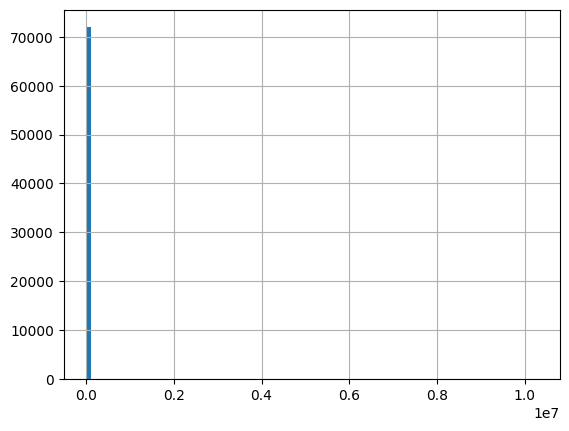

In [71]:
df.coordinateUncertaintyInMeters.hist(bins=100)

<Axes: >

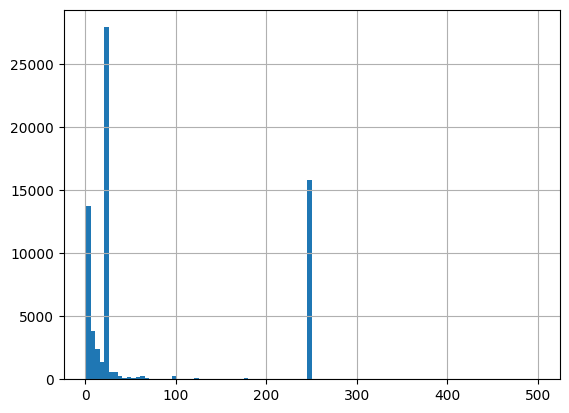

In [72]:
df[df.coordinateUncertaintyInMeters < 500].coordinateUncertaintyInMeters.hist(bins=100)

In [73]:
df[df.coordinateUncertaintyInMeters < 100].shape

(51991, 147)

In [74]:
df[df.coordinateUncertaintyInMeters < 500].shape

(69205, 147)

In [75]:
df[(df.coordinateUncertaintyInMeters >= 500) & (df.coordinateUncertaintyInMeters <= 1000)].shape

(540, 147)

In [76]:
df[df.coordinateUncertaintyInMeters > 1000].shape

(2225, 147)

#### isSequenced

In [77]:
print(round((df.shape[0] - df.isSequenced.isna().sum()) / df.shape[0] * 100, 2))

100.0


In [78]:
df.groupby("species")["isSequenced"].value_counts().to_frame().assign(
    percent=lambda x: x["count"] / x.groupby("species")["count"].transform("sum") * 100
)

# isSequenced is almost always False and secondary. We can drop this

count    percent
species        isSequenced                  
Vespa crabro   False        61160   99.87589
               True            76    0.12411
Vespa velutina False        17866  100.00000

### Clean Columns

#### eventDate

In [79]:
df.eventDate.fillna("No Date", inplace=True)

eventDates_slash = [x for x in df.eventDate if "/" in x]
eventDates_T = [x for x in df.eventDate if "T" in x]

len(df.eventDate), len(eventDates_slash), len(eventDates_T)

(79102, 0, 48773)

In [80]:
# "T" Format: "2021-06-14T10:00:00" to "2021-06-14"
mask_T     = df.eventDate.str.contains("T", na=False)
df.loc[mask_T, "eventDate"] = df.loc[mask_T, "eventDate"].str.split("T").str[0]

# Date span "1997-07-26/1997-08-04" to first Date
mask_range = df.eventDate.str.match(r"^\d{4}-\d{2}-\d{2}/\d{4}-\d{2}-\d{2}$", na=False)
df.loc[mask_range, "eventDate"] = df.loc[mask_range, "eventDate"].str.split("/").str[0]

# "/" Format: "14/06/2021" to "2021-06-14"
mask_slash = df.eventDate.str.contains("/", na=False)
df.loc[mask_slash, "eventDate"] = pd.to_datetime(
    df.loc[mask_slash, "eventDate"], dayfirst=True
).dt.strftime("%Y-%m-%d")

# ----- datetime 
df["eventDate"] = pd.to_datetime(df["eventDate"], errors="coerce")

In [81]:
# Remove Rows with eventDate irregularities

shape_before_a = df.shape

df = df[df.day.notna()]
shape_after_a = df.shape
print(f"{shape_before_a[0]-shape_after_a[0]} were removed (NAN days)")

df = df[df.month.notna()]
shape_after_b = df.shape
print(f"{shape_after_a[0]-shape_after_b[0]} were removed (NAN months)")

df = df.dropna(subset=["year"])
shape_after_c = df.shape
print(f"{shape_after_b[0]-shape_after_c[0]} were removed (NAN years)")

print(f"{shape_before_a[0]-shape_after_c[0]} were removed in Total")
df.reset_index(drop=True, inplace=True)

144 were removed (NAN days)
0 were removed (NAN months)
0 were removed (NAN years)
144 were removed in Total


In [82]:
df["year"] = df["year"].astype(int)
df["year_month"] = df["eventDate"].dt.to_period("M").astype(str)

In [83]:
df.columns

Index(['key', 'datasetKey', 'publishingOrgKey', 'installationKey',
       'hostingOrganizationKey', 'publishingCountry', 'protocol',
       'lastCrawled', 'lastParsed', 'crawlId',
       ...
       'eventRemarks', 'higherClassification', 'georeferencedBy',
       'georeferencedDate', 'municipality', 'county', 'locationAccordingTo',
       'photo', 'varified', 'year_month'],
      dtype='object', length=148)

### Clean Rows

In [84]:
print(df.shape)
df = df[df.year >= 2021]
print(df.shape)

(78958, 148)
(61195, 148)


In [85]:
df_NABU = df[df["identifiers"].str.contains("NABU")].copy()

In [86]:
df["Org"] = df["identifiers"].str.contains("NABU", regex=False).map({True: "NABU", False: "Non NABU"})
df_NABU = df[df["Org"]=="NABU"].copy()

In [87]:
df_NABU.shape

(28688, 149)

In [88]:
def plot_species_timeline(df, palette=COLORS, save_path=None, subspecies=False):
    df = df.copy()
    df["year_month"] = pd.to_datetime(df["year_month"], format="%Y-%m")
    
    group_col = "scientificName" if subspecies else "species"
    groups = df[group_col].unique()

    fig, axes = plt.subplots(len(groups), 1, figsize=(14, 4 * len(groups)), sharex=False)
    axes = np.atleast_1d(axes)

    for ax, group in zip(axes, groups):
        sub = df[df[group_col] == group]
        for name in sub["scientificName"].unique():
            d = sub[sub["scientificName"] == name].set_index("year_month")["count"]
            ax.bar(d.index, d.values, width=20, label=name, color=palette.get(name, "#AAAAAA"), alpha=0.8)
        
        ax.set_title(group, fontsize=11, fontweight="bold", loc="left")
        ax.set_ylabel("Observations")
        ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter("%b '%y"))
        plt.setp(ax.get_xticklabels(), rotation=35, ha="right")
        ax.legend(fontsize=7.5, loc="upper left")
        ax.yaxis.grid(True, linewidth=0.5, alpha=0.5)

    fig.suptitle("Vespa Observations Over Time", fontsize=14, fontweight="bold")
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")

    return plt.show()

In [89]:
df_scientificName_tl = (
    df.groupby("species")[["year_month", "scientificName"]]
    .value_counts()
    .reset_index()
    .sort_values(["species", "year_month"])
)

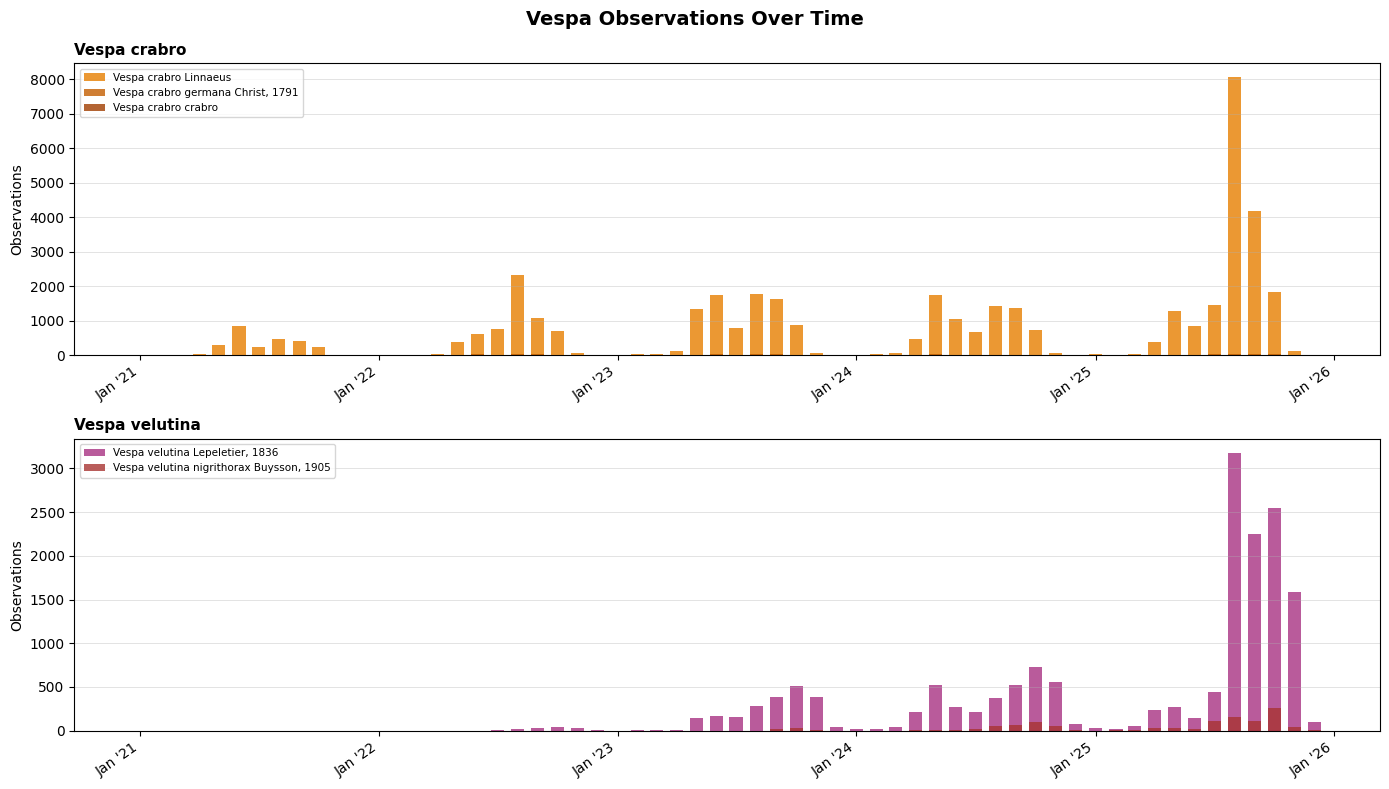

In [90]:
plot_species_timeline(df_scientificName_tl)

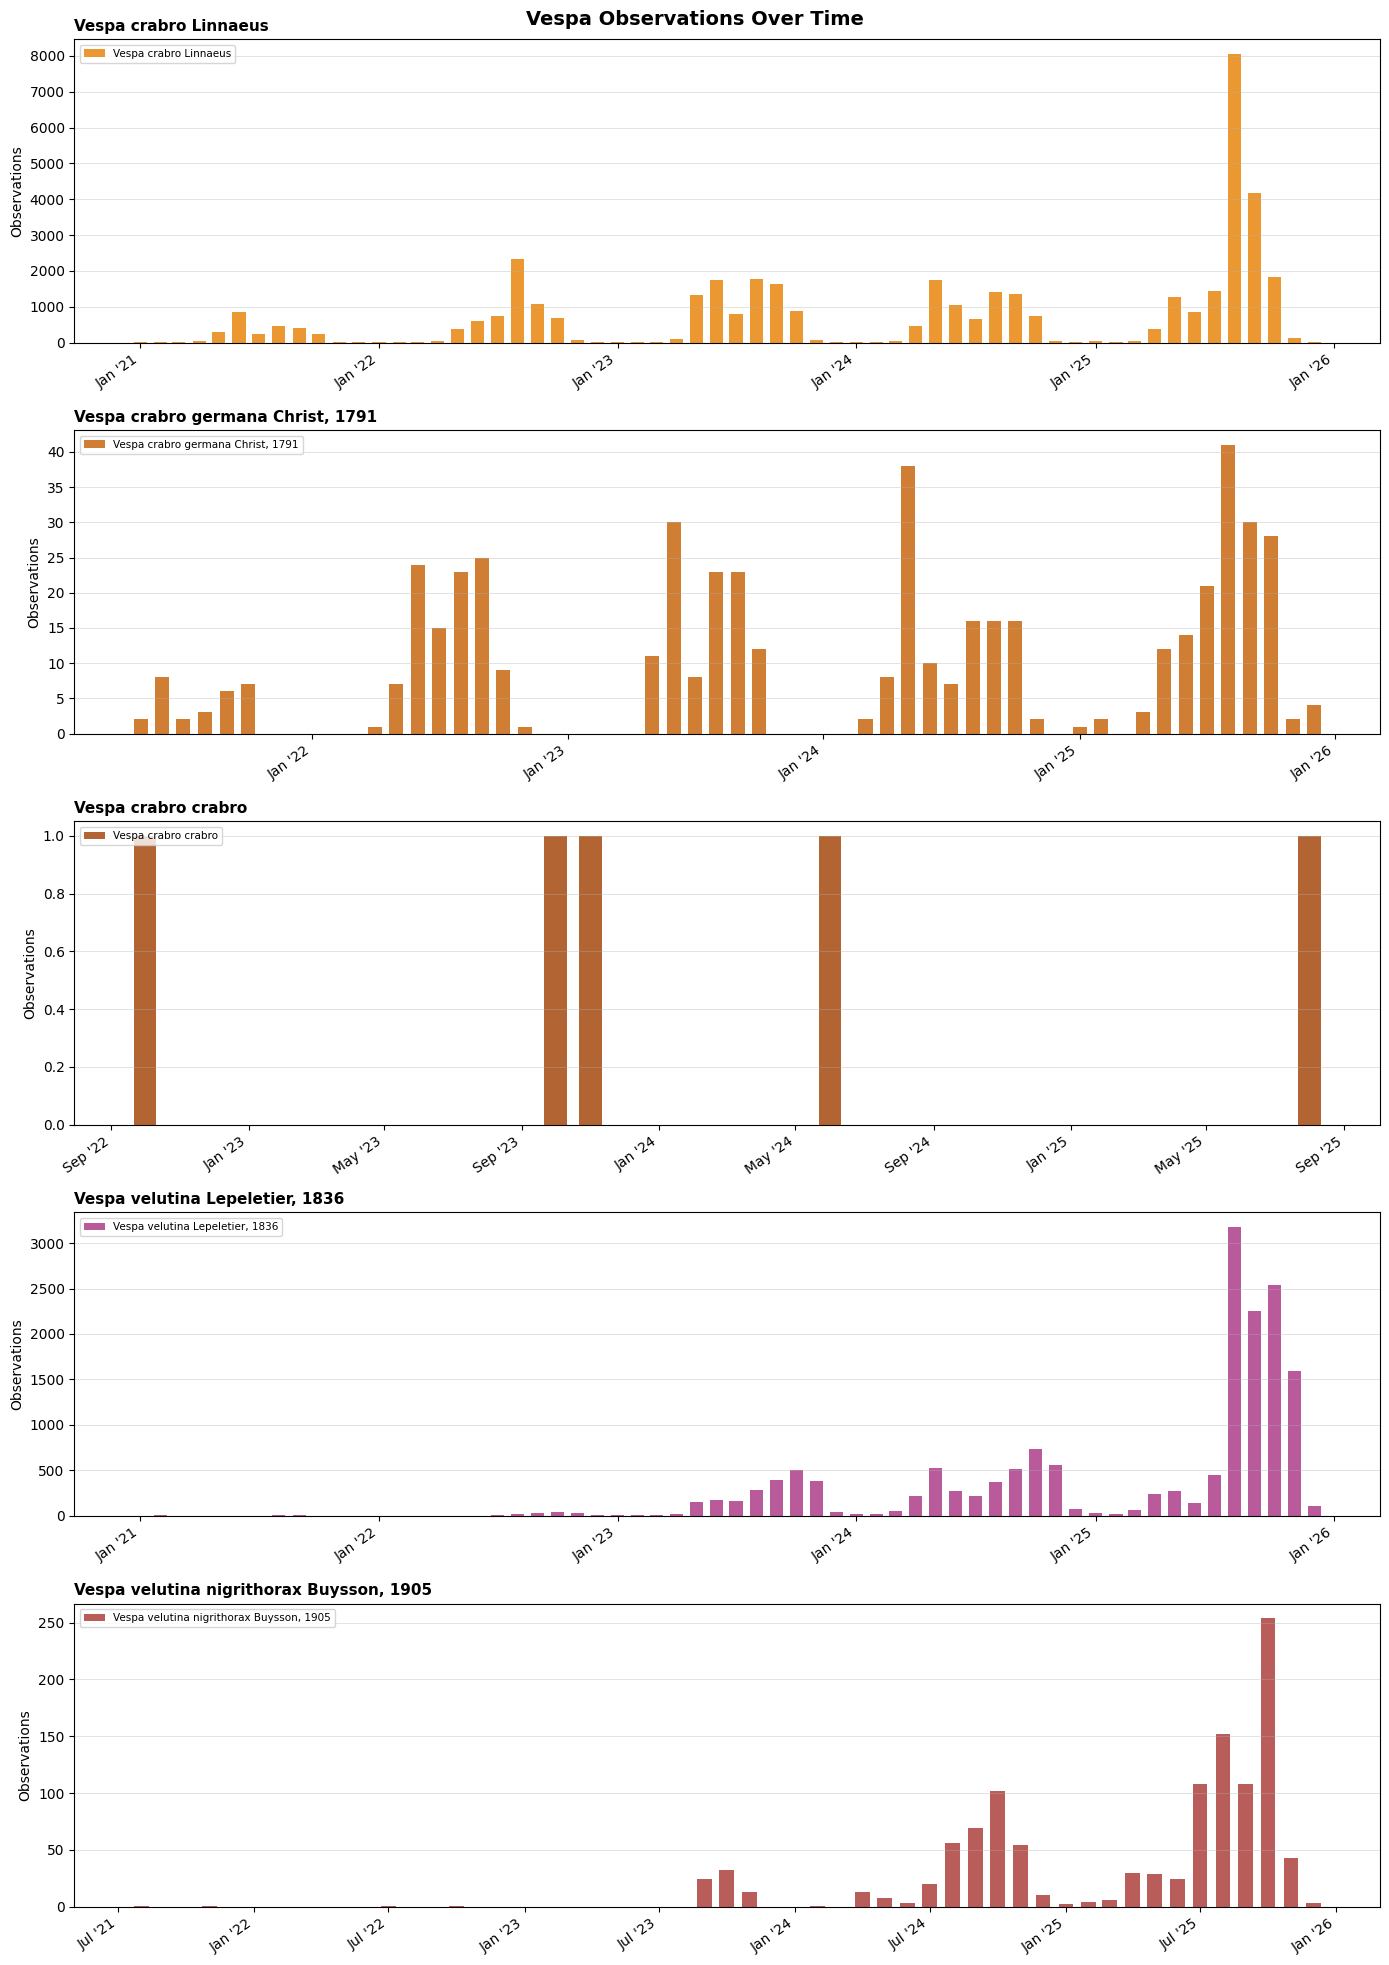

In [91]:
plot_species_timeline(df_scientificName_tl, subspecies=True)

In [92]:
df_identified_NABU = df_NABU[df_NABU.varified == "Varified"].copy()
df_identified_NABU.shape

(0, 149)

In [93]:
df_NABU.groupby("species")[["varified", "photo"]].value_counts(dropna=False).to_frame().assign(
    percent=lambda x: x["count"] / x.groupby("species")["count"].transform("sum") * 100
).sort_index(level=["species", "varified", "photo"])

count    percent
species        varified     photo                     
Vespa crabro   Not Varified No Photo  14037  76.696536
                            Photo      4265  23.303464
Vespa velutina Not Varified No Photo   6773  65.212786
                            Photo      3613  34.787214

In [94]:
df_NABU_tl = (
    df_NABU[df_NABU.photo == "Photo"].groupby("species")[["year_month", "scientificName"]]
    .value_counts()
    .reset_index()
    .sort_values(["species", "year_month"])
)

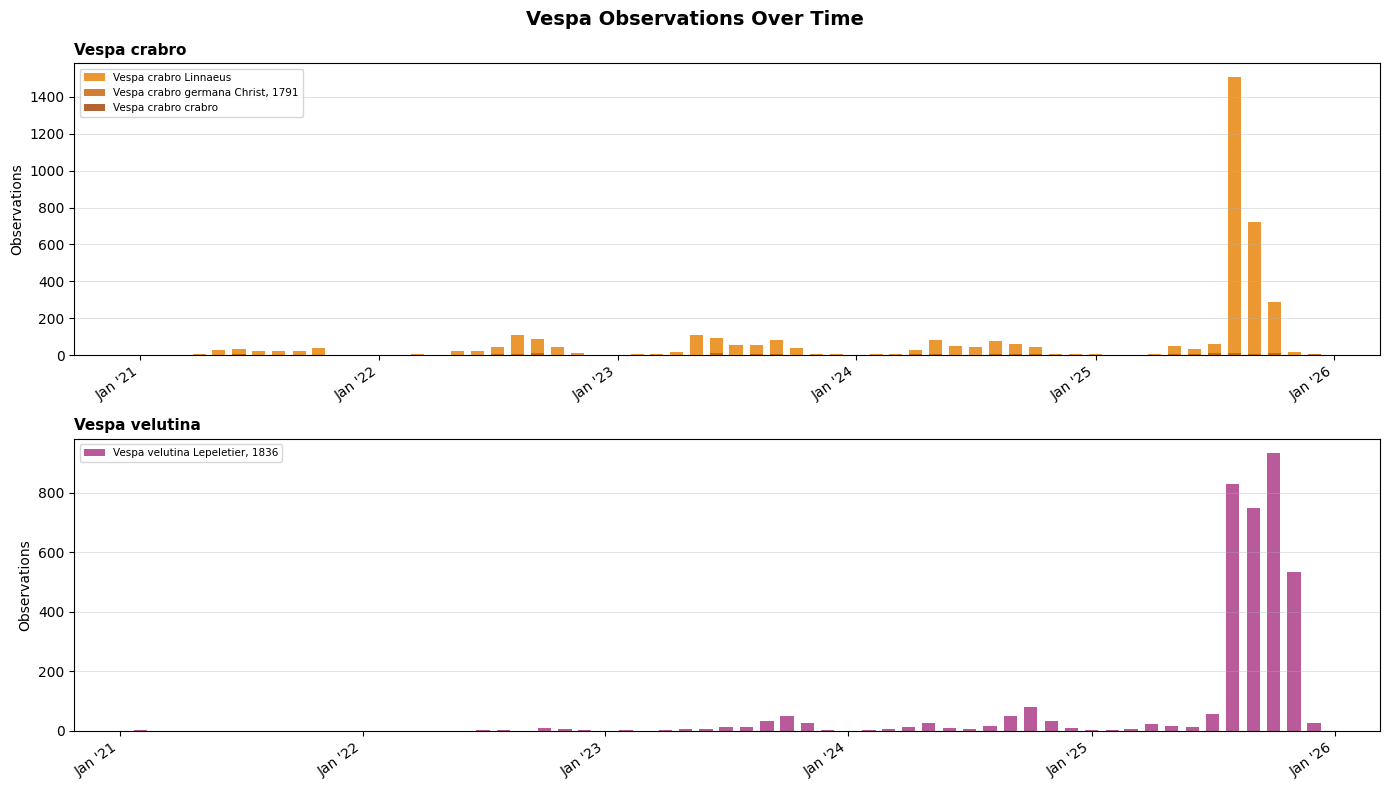

In [95]:
plot_species_timeline(df_NABU_tl)

In [96]:
df_identified = df[df.varified == "Varified"].copy()
df_identified.shape

(19808, 149)

In [97]:
df_identified.groupby("species")[["Org","varified", "photo"]].value_counts(dropna=False).to_frame().assign(
    percent=lambda x: x["count"] / x.groupby("species")["count"].transform("sum") * 100
).sort_index(level=["species", "varified", "photo"])

count    percent
species        Org      varified photo                     
Vespa crabro   Non NABU Varified No Photo   2024  11.030574
                                 Photo     16325  88.969426
Vespa velutina Non NABU Varified No Photo    337  23.098012
                                 Photo      1122  76.901988

In [98]:
df_identified.groupby("species")[["varified", "photo"]].value_counts(dropna=False).to_frame().assign(
    percent=lambda x: x["count"] / x.groupby("species")["count"].transform("sum") * 100
).sort_index(level=["species", "varified", "photo"])

count    percent
species        varified photo                     
Vespa crabro   Varified No Photo   2024  11.030574
                        Photo     16325  88.969426
Vespa velutina Varified No Photo    337  23.098012
                        Photo      1122  76.901988

In [99]:
df_identified_tl = (
    df_identified.groupby("species")[["year_month", "scientificName"]]
    .value_counts()
    .reset_index()
    .sort_values(["species", "year_month"])
)

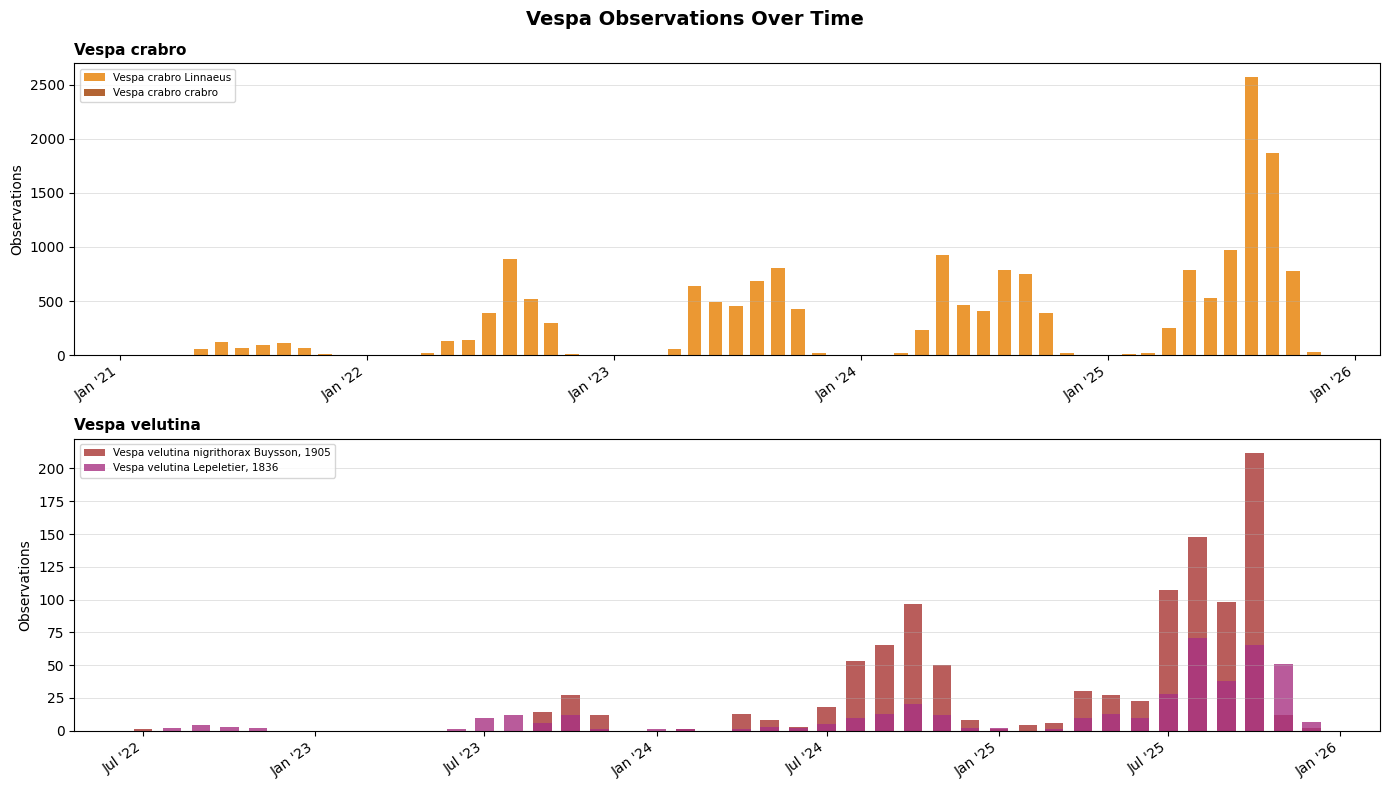

In [100]:
plot_species_timeline(df_identified_tl)

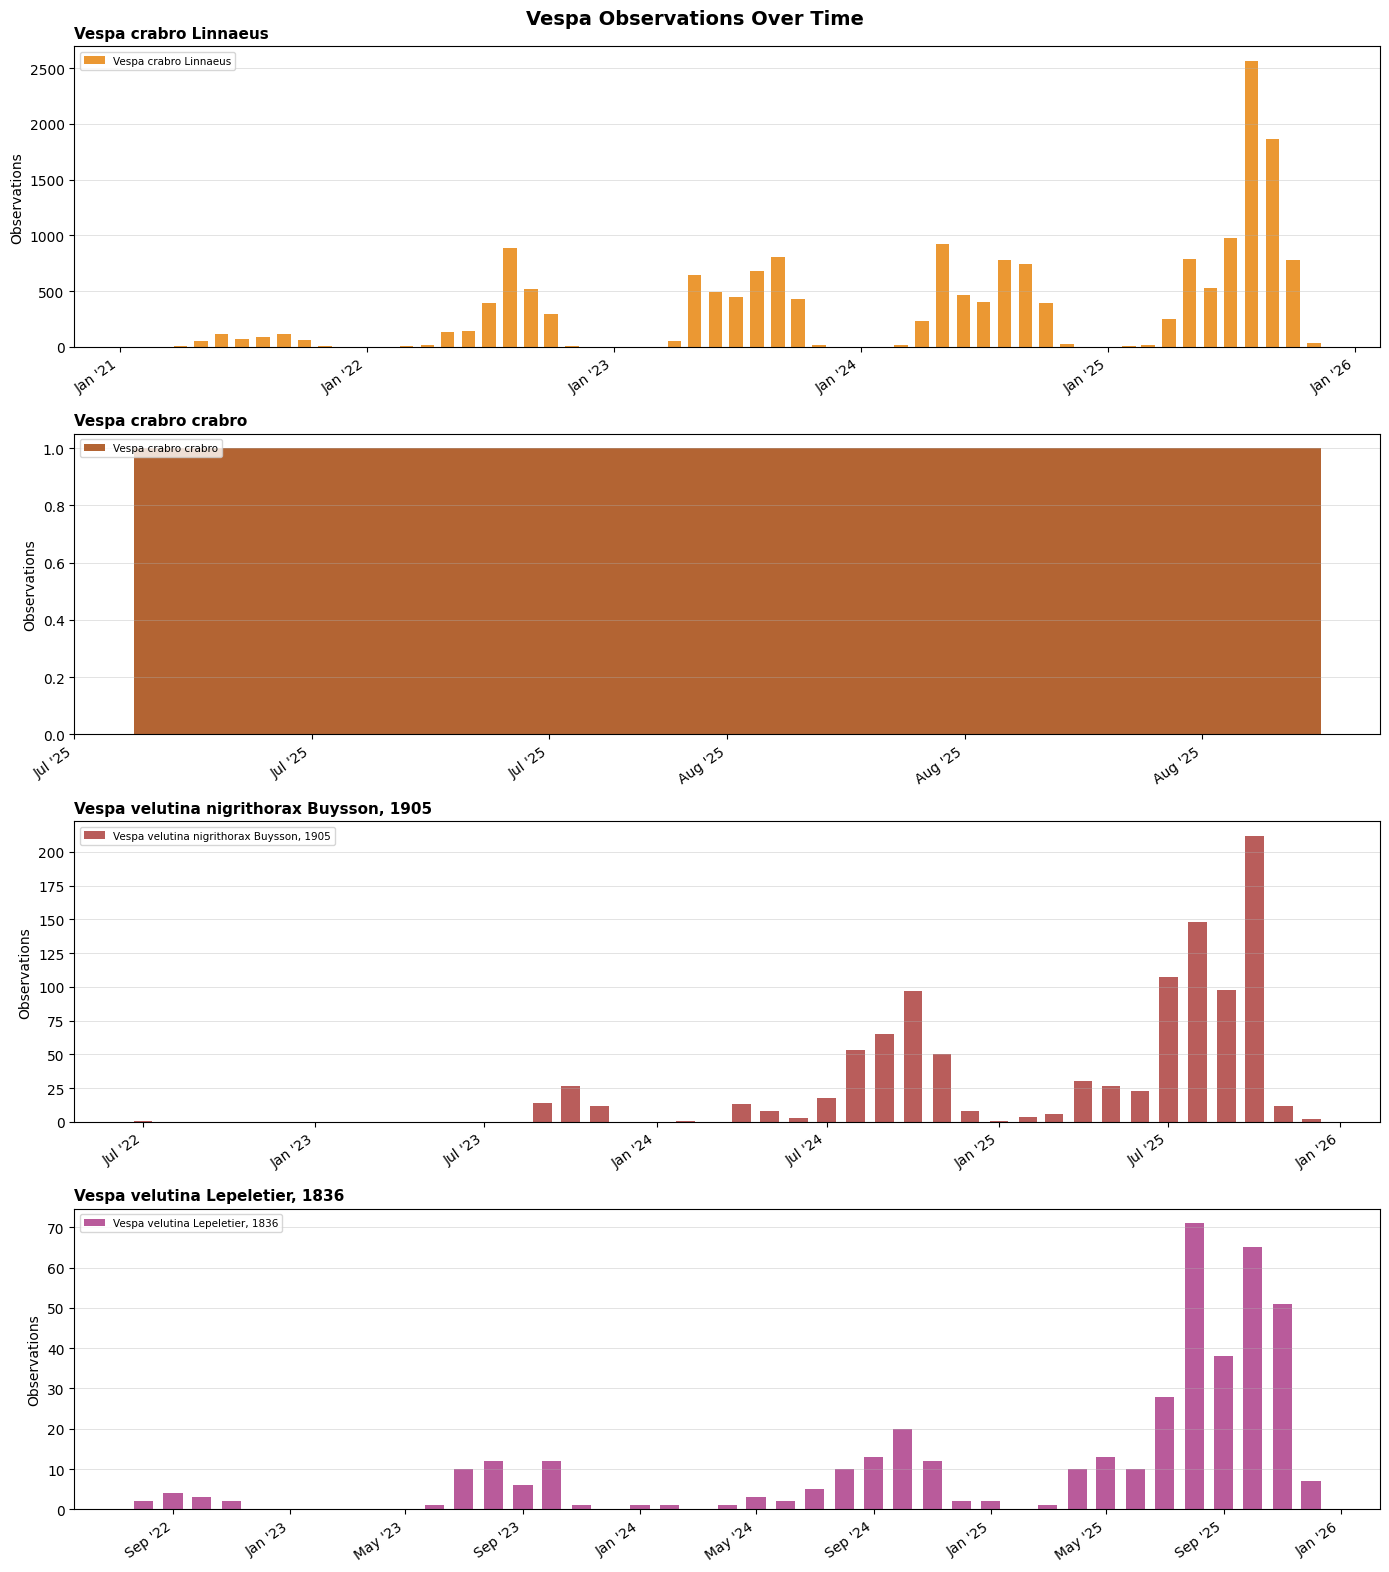

In [101]:
plot_species_timeline(df_identified_tl, subspecies=True)

## Conclusion

### Overview:

**GBIF API provides up to 145 Columns**

* 73 Columns are more than 50% empty
* 77 Columns are more than 20% empty

**Interpolating to fill 50%+ empty columns could be difficult and the 4 20%+ columns are not viable, therefore drop them**
* 68 Columns are "not empty"


##### The 68 filled columns can be grouped into

* spatial
* temporal
* taxonomic
* taxonomic_keys
* observation_meta
* data_quality
* provenance

**Only some spatial, temporal and taxonomic are needed for analysis**

-----------------------------

### Column Specific:

##### spatial:
* decimalLatitude, decimalLongitude seems enough -> "geodeticDatum" not needed: geodeticDatum always WGS84
* coordinateUncertaintyInMeters (10%) empty, could be automatically generated from the hardware location

##### temporal:
* eventDate main date column. Cleaning is needed to unify format.
* Some day values are empty: Dropping day, month and year could make sense as they can be reconstructed

##### taxonomic:
* species seems enough -> acceptedScientificName, genericName and scientificNameAuthorship not needed
* species seems enough -> genus, family and specificEpithet not needed
* species seems enough -> order, phylum and class not needed
* species seems enough -> kingdom, taxonRank and taxonomicStatus not needed
* Drop rows with taxonRank: UNRANKED Rows (is also scientificName: BOLD:ABA8441)
* scientificName is heavily one sided for each species (99% and 93%)

##### observation_meta:
* recordedBy, recordedByIDs, identifiedByIDs and dnaSequenceID provide no insight value, can be droppped
* identifiers can maybe be used to map to NABU Naturgucker App
* media is photo reference, but we can focus on other column to varify sightings (identificationVerificationStatus)
* media columns sometimes empty for varified rows and sometimes they are varified without photo reference...
* basisOfRecord mostly HUMAN_OBSERVATION, occurrenceStatus always PRESENT -> keep basisOfRecord: HUMAN_OBSERVATION

##### data_quality, provenance and taxonomic_keys:
* cols are secondary columns, not needed for further analysis


**Core Columns for analysis:**
* 'species'
* 'decimalLatitude'
* 'decimalLongitude'
* 'eventDate'
* 'scientificName' (maybe)
* 'coordinateUncertaintyInMeters' (maybe)

**Columns for filtering**
* 'taxonRank' != UNRANKED
* 'identifiers' to map to NABU Naturgucker App observations
* 'media' for photo reference, but we cannot check each photo if it actually shows the right species
* 'identificationVerificationStatus' to get varified sightings
* 'basisOfRecord' for human obseervation check


#### Other Columns:

##### identificationVerificationStatus:
* Difference between varified observations and media/photo reference
* identificationVerificationStatus seems like the main way to varify sightings
* identificationVerificationStatus is ~75% empty
* From those that are not empty, asian hornets are mostly "Approved | Expert | Evidence" while european hornets are mostly "Approved | Automated"
* From those that are not empty, asian hornets 77% have a photo reference while 88% european hornet observations have a photo reference


##### coordinateUncertaintyInMeters:
* over half are below 100 meters
* mostly below below 500 meters
* some outliers (2000) are over 1000 meters
* the values seem to be automatically generated, therefore maybe ignoreable

-----------------------------

### Row Specific:

* Focus on data with year > 2020 (NABU said 2022 onwards, but keeping 2021 may be good to visualize the increase)
* Focus on data with year > 2020, reduces the rows from 79k to 61k.
* From the ~61k data, around 28k rows seem to be from NABU
* None of the 28k NABU data rows have values for identificationVerificationStatus (not varified) 
* Only 23% of the european and 34% of the asian hornet observations have photo references for the 28k NABU data
* (**Only focusing on NABU data could therefore be problematic**)
* If we only focus on NABU data with photo reference, we have no varified data, and the rows would be reduced to ~8k
* If we only focus on varified data, we have no NABU Naturgucker data, but keep photo refencences and rows would be reduced to 20k or 17k (with only photo reference)




## Potential Core DF for further analysis

In [102]:
def clean_eventDate(df):

    shape_before = df.shape

    df.eventDate.fillna("No Date", inplace=True)

    eventDates_slash = [x for x in df.eventDate if "/" in x]
    eventDates_T = [x for x in df.eventDate if "T" in x]

    print(f"N eventDates: {len(df.eventDate)}")
    print(f"N eventDates /: {len(eventDates_slash)}")
    print(f"N eventDates T: {len(eventDates_T)}")

    # "T" Format: "2021-06-14T10:00:00" to "2021-06-14"
    mask_T     = df.eventDate.str.contains("T", na=False)
    df.loc[mask_T, "eventDate"] = df.loc[mask_T, "eventDate"].str.split("T").str[0]

    # Date Span "1997-07-26/1997-08-04" to first Date
    mask_range = df.eventDate.str.match(r"^\d{4}-\d{2}-\d{2}/\d{4}-\d{2}-\d{2}$", na=False)
    df.loc[mask_range, "eventDate"] = df.loc[mask_range, "eventDate"].str.split("/").str[0]

    # "/" Format: "14/06/2021" to "2021-06-14"
    mask_slash = df.eventDate.str.contains("/", na=False)
    df.loc[mask_slash, "eventDate"] = pd.to_datetime(
        df.loc[mask_slash, "eventDate"], dayfirst=True
    ).dt.strftime("%Y-%m-%d")

    # datetime 
    df["eventDate"] = pd.to_datetime(df["eventDate"], errors="coerce")

    df["day"]   = df["eventDate"].dt.day
    df["month"] = df["eventDate"].dt.month
    df["year"] = df["year"].astype(int)
    df["year_month"] = df["eventDate"].dt.to_period("M").astype(str)
    df["year_KW"] = df["eventDate"].dt.isocalendar().year.astype(str) + "_" + df["eventDate"].dt.isocalendar().week.astype(str)

    shape_after = df.shape
    print(shape_before)
    print(shape_after)

    return df


In [103]:
def define_varification_cols(df):

    df["photo"] = df["media"].str.contains("[]", regex=False).map({True: "No Photo", False: "Photo"})
    df["org"] = df["identifiers"].str.contains("NABU", regex=False).map({True: "NABU", False: "Non NABU"})

    varified_values = ["Approved | Automated", 
                        "Approved | Expert", 
                        "Approved | Expert | Evidence",
                        "Valid"]
    pattern = "|".join(map(re.escape, varified_values))
    df["varified"] = np.where(df["identificationVerificationStatus"].str.contains(pattern, na=False), "Varified", "Not Varified")

    bins   = [0, 10, 50, 100, 500, 1000, np.inf]
    labels = ["≤10m", "10-50m", "50-100m", "100-500m", "500-1000m", ">1000m"]
    df["uncertainty_buckets"] = pd.cut(df["coordinateUncertaintyInMeters"], bins=bins, labels=labels, ordered=True)
    df["uncertainty_buckets"] = df["uncertainty_buckets"].cat.add_categories("Unknown").fillna("Unknown")

    return df


In [104]:
base_shape = df_base.shape
base_shape

(79102, 145)

In [105]:
df_fin = df_base.copy()
print(df_fin.shape)

(79102, 145)


In [106]:
# add varification columns

df_fin = define_varification_cols(df_fin)
print(df_fin.shape)

(79102, 149)


In [107]:
# filter to 2021+

df_fin = clean_eventDate(df_fin)
df_fin = df_fin[df_fin["year"] >= 2021]
print(df_fin.shape)

N eventDates: 79102
N eventDates /: 0
N eventDates T: 48773
(79102, 149)
(79102, 151)
(61213, 151)


In [108]:
# filter out 'taxonRank': UNRANKED
df_fin[df_fin["taxonRank"]!="UNRANKED"]
print(df_fin.shape)

(61213, 151)


In [109]:
# check NABU only

df_fin_NABU = df_fin[df_fin["org"] == "NABU"]
print(df_fin_NABU.shape)

(28688, 151)


In [110]:
# check varified only

df_fin_V = df_fin[df_fin["varified"] == "Varified"]
print(df_fin_V.shape)

(19808, 151)


In [111]:
# keep other Columns if you want, but for analysis purposes they dont provide too much value
# adding additional data sources to answer the different RQ would make sense

core_cols

['scientificName',
 'species',
 'decimalLatitude',
 'decimalLongitude',
 'coordinateUncertaintyInMeters',
 'eventDate']

In [112]:
filter_cols = [ "day", "month", "year",
                "year_KW",
                "year_month", 
                "basisOfRecord", 
                "org", 
                "identifiers", 
                "varified", 
                "identificationVerificationStatus", 
                "uncertainty_buckets",
                "photo",
                "media"]

In [113]:
keep_cols = core_cols + filter_cols

In [114]:
df_fin = df_fin[keep_cols]
df_fin_NABU = df_fin_NABU[keep_cols]
df_fin_V = df_fin_V[keep_cols]

In [115]:
print(f"df_fin shape: {df_fin.shape}")
print(f"df_fin_NABU shape: {df_fin_NABU.shape}")
print(f"df_fin_V shape: {df_fin_V.shape}")

df_fin shape: (61213, 19)
df_fin_NABU shape: (28688, 19)
df_fin_V shape: (19808, 19)


In [116]:
df_fin.groupby("species")[["varified", "photo"]].value_counts(dropna=False).to_frame().assign(
    percent=lambda x: x["count"] / x.groupby("species")["count"].transform("sum") * 100
).sort_index(level=["species", "varified", "photo"])

count    percent
species        varified     photo                     
Vespa crabro   Not Varified No Photo  16112  37.136403
                            Photo      8925  20.571152
               Varified     No Photo   2024   4.665099
                            Photo     16325  37.627345
Vespa velutina Not Varified No Photo  12064  67.672631
                            Photo      4304  24.143154
               Varified     No Photo    337   1.890391
                            Photo      1122   6.293824

In [117]:
df_fin_NABU.groupby("species")[["varified", "photo"]].value_counts(dropna=False).to_frame().assign(
    percent=lambda x: x["count"] / x.groupby("species")["count"].transform("sum") * 100
).sort_index(level=["species", "varified", "photo"])

count    percent
species        varified     photo                     
Vespa crabro   Not Varified No Photo  14037  76.696536
                            Photo      4265  23.303464
Vespa velutina Not Varified No Photo   6773  65.212786
                            Photo      3613  34.787214

In [118]:
df_fin_V.groupby("species")[["varified", "photo"]].value_counts(dropna=False).to_frame().assign(
    percent=lambda x: x["count"] / x.groupby("species")["count"].transform("sum") * 100
).sort_index(level=["species", "varified", "photo"])

count    percent
species        varified photo                     
Vespa crabro   Varified No Photo   2024  11.030574
                        Photo     16325  88.969426
Vespa velutina Varified No Photo    337  23.098012
                        Photo      1122  76.901988

In [119]:
df_fin_V.groupby("species")[["varified", "photo", "org"]].value_counts(dropna=False).to_frame().assign(
    percent=lambda x: x["count"] / x.groupby("species")["count"].transform("sum") * 100
).sort_index(level=["species", "varified", "photo"])

count    percent
species        varified photo    org                       
Vespa crabro   Varified No Photo Non NABU   2024  11.030574
                        Photo    Non NABU  16325  88.969426
Vespa velutina Varified No Photo Non NABU    337  23.098012
                        Photo    Non NABU   1122  76.901988